# 2. Un ejemplo de control óptimo discreto

Antes de ir a EDPs, fijamos las ideas en un ejemplo **puramente discreto**, donde todas las
derivadas son algebraicas y la ecuación adjunta resulta ser una recurrencia.

## 2.1 El problema

Consideremos el sistema dinámico

$$
x_{k+1}=a\,x_k+b\,m_k, \qquad k=0,1,\dots,N-1,\qquad x_0 \text{ fijo},
$$

con estado $x=(x_1,\dots,x_N)$ y controles $m=(m_0,\dots,m_{N-1})$. Queremos que la
trayectoria siga una referencia $x^d=(x_1^d,\dots,x_N^d)$ sin gastar demasiado control:

$$
E(m)=\sum_{k=1}^{N}\big(x_k-x_k^d\big)^2
+\frac{\alpha}{2}\sum_{k=0}^{N-1}m_k^2 .
$$

En la forma general, $g(x,m)=0$ tiene componentes

$$
g_k=x_{k+1}-a\,x_k-b\,m_k=0,\qquad k=0,\dots,N-1 .
$$

Las incógnitas del estado son $(x_1,\dots,x_N)$ (recuérdese que $x_0$ está fijo) y los
multiplicadores son $(\lambda_1,\dots,\lambda_N)$.

## 2.2 El Lagrangiano

Con un multiplicador $\lambda_{k+1}$ por cada restricción $g_k$,

$$
\mathcal L(x,m,\lambda)
=E(m)+\sum_{k=0}^{N-1}\lambda_{k+1}\big(x_{k+1}-a\,x_k-b\,m_k\big).
$$ (eq:lagr-control)

## 2.3 Estacionariedad respecto del estado

Derivamos respecto de cada $x_j$. Cada $x_j$ aparece en el objetivo (el término $j$) y en
dos restricciones: $g_{j-1}=x_j-a x_{j-1}-b m_{j-1}$ (donde aparece $+\lambda_j x_j$) y
$g_j=x_{j+1}-a x_j-b m_j$ (donde aparece $-a\lambda_{j+1}x_j$). Por lo tanto, para
$j=1,\dots,N-1$,

$$
\frac{\partial\mathcal L}{\partial x_j}
=2\big(x_j-x_j^d\big)+\lambda_j-a\,\lambda_{j+1}=0,
$$ (eq:dLdx)

mientras que para $j=N$ no existe $g_N$, de modo que

$$
\frac{\partial\mathcal L}{\partial x_N}
=2\big(x_N-x_N^d\big)+\lambda_N=0
\qquad\Longrightarrow\qquad
\lambda_N=-2\big(x_N-x_N^d\big).
$$ (eq:terminal)

Reordenando {eq}`eq:dLdx` obtenemos la **recurrencia adjunta hacia atrás**:

$$
\boxed{\;
\lambda_k=a\,\lambda_{k+1}-2\big(x_k-x_k^d\big),
\qquad k=N-1,\dots,1,
\qquad
\lambda_N=-2\big(x_N-x_N^d\big).
\;}
$$ (eq:adjoint-control)

El adjunto se propaga **desde el tiempo final hacia atrás** y su "fuente" es el residuo
$2(x_k-x_k^d)$. Comparar con el problema directo, que se integra hacia adelante.

## 2.4 El gradiente

La derivada parcial respecto de $m_k$ es

$$
\frac{\partial\mathcal L}{\partial m_k}
=\alpha\,m_k-b\,\lambda_{k+1}.
$$

Como en el óptimo $\nabla_x\mathcal L=0$, esta es directamente la derivada de $\hat E$, es
decir,

$$
\boxed{\;\nabla_{m_k}\hat E=\alpha\,m_k-b\,\lambda_{k+1},
\qquad k=0,\dots,N-1 .\;}
$$ (eq:grad-control)

El algoritmo es entonces: **(1)** resolver el directo ($x$ hacia adelante); **(2)** resolver
el adjunto ($\lambda$ hacia atrás); **(3)** evaluar el gradiente {eq}`eq:grad-control`.
Implementemos y verifiquemos contra diferencias finitas.

In [1]:
import warnings
warnings.filterwarnings("ignore")   # silencia avisos de versiones duplicadas de matplotlib

import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Control discreto:  x_{k+1} = a x_k + b m_k ,  x_0 fijo
# E(m) = sum (x_k - x_k^d)^2 + (alpha/2) sum m_k^2
# =========================================================
N = 50
h = 1.0 / N
a, b = 1.0, h
alpha = 1e-4

k = np.arange(N + 1)
xd = 0.5 * (1.0 - np.cos(np.pi * k / N))      # trayectoria deseada


def forward(m):
    # problema directo: integra la recurrencia hacia adelante
    x = np.empty(N + 1)
    x[0] = 0.0
    for k in range(N):
        x[k + 1] = a * x[k] + b * m[k]
    return x


def objective(m):
    x = forward(m)
    return np.sum((x[1:] - xd[1:]) ** 2) + 0.5 * alpha * np.sum(m ** 2)


def adjoint_gradient(m):
    # adjunto (hacia atras) + gradiente de E respecto de m
    x = forward(m)
    lam = np.empty(N + 1)
    lam[N] = -2.0 * (x[N] - xd[N])             # condicion terminal
    for k in range(N - 1, 0, -1):              # recurrencia hacia atras
        lam[k] = a * lam[k + 1] - 2.0 * (x[k] - xd[k])
    grad = alpha * m - b * lam[1:]
    return grad, x, lam


# ---- verificacion del gradiente contra diferencias finitas ----
rng = np.random.default_rng(0)
m0 = rng.normal(0.0, 1.0, N)
g, _, _ = adjoint_gradient(m0)

eps_fd = 1e-6
g_fd = np.empty(N)
for i in range(N):
    mp = m0.copy(); mp[i] += eps_fd
    mm = m0.copy(); mm[i] -= eps_fd
    g_fd[i] = (objective(mp) - objective(mm)) / (2 * eps_fd)

print("Gradiente adjunto vs. diferencias finitas")
print(f"  error absoluto maximo: {np.max(np.abs(g - g_fd)):.3e}")
print(f"  error relativo maximo: {np.max(np.abs(g - g_fd)) / np.max(np.abs(g_fd)):.3e}")

Gradiente adjunto vs. diferencias finitas
  error absoluto maximo: 5.171e-09
  error relativo maximo: 4.762e-09


E(m_0)  = 19.250000
E(m_*)  = 0.003143
error de seguimiento max |x-x^d| = 3.760e-03


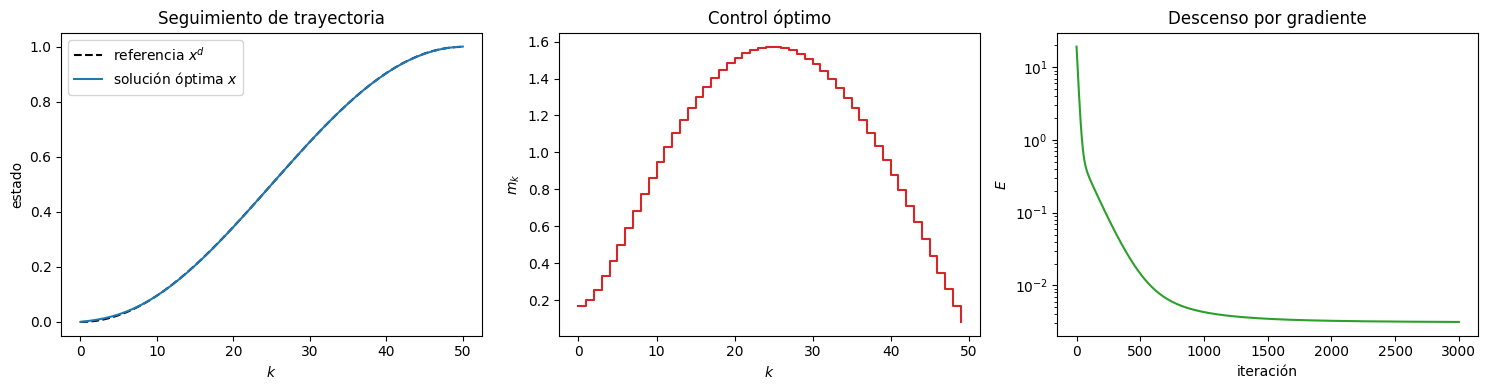

In [2]:
# ---- descenso por gradiente ----
m = np.zeros(N)
hist = [objective(m)]
for it in range(3000):
    g, x, lam = adjoint_gradient(m)
    m = m - 0.05 * g
    hist.append(objective(m))

x_opt = forward(m)
print(f"E(m_0)  = {hist[0]:.6f}")
print(f"E(m_*)  = {hist[-1]:.6f}")
print(f"error de seguimiento max |x-x^d| = {np.max(np.abs(x_opt - xd)):.3e}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(k, xd, "k--", label="referencia $x^d$")
ax[0].plot(k, x_opt, "C0-", label="solución óptima $x$")
ax[0].set_xlabel("$k$"); ax[0].set_ylabel("estado"); ax[0].legend()
ax[0].set_title("Seguimiento de trayectoria")

ax[1].step(np.arange(N), m, where="post", color="C3")
ax[1].set_xlabel("$k$"); ax[1].set_ylabel("$m_k$")
ax[1].set_title("Control óptimo")

ax[2].semilogy(hist, color="C2")
ax[2].set_xlabel("iteración"); ax[2].set_ylabel("$E$")
ax[2].set_title("Descenso por gradiente")
plt.tight_layout(); plt.show()